# Partie D — Segmentation client par machine learning

Objectif : Construire une segmentation client exploitable d'un point de vue metier.
Methode : K-Means clustering avec justification du nombre de segments retenus.
Chaque segment doit avoir un profil clair et des actions marketing differenciees.

In [1]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

df = pd.read_csv('../data/processed/df_clean.csv')
print(f"Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes")

Dataset chargé : 2212 lignes x 32 colonnes


In [2]:
# ── 1. SELECTION DES VARIABLES POUR LE CLUSTERING ────────
# Justification : variables comportementales et socio-demo clés
# identifiées en Partie C. On exclut la variable cible Response.
clustering_vars = [
    'Income', 'TotalSpend', 'Recency',
    'MntWines', 'MntMeatProducts', 'MntFruits',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'CmpAccepted_Total', 'TotalChildren', 'Age', 'Seniority_Days'
]

X = df[clustering_vars].copy()

# Normalisation StandardScaler
# Justification : K-Means est sensible aux échelles, la normalisation
# évite que Income (50 000) domine Recency (0-100)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_vars)

print(f"Variables sélectionnées : {len(clustering_vars)}")
print(f"Matrice normalisée : {X_scaled.shape}")
print(f"\nMoyenne après normalisation (doit être ~0) : {X_scaled.mean(axis=0).mean():.4f}")
print(f"Ecart-type après normalisation (doit être ~1) : {X_scaled.std(axis=0).mean():.4f}")

Variables sélectionnées : 16
Matrice normalisée : (2212, 16)

Moyenne après normalisation (doit être ~0) : -0.0000
Ecart-type après normalisation (doit être ~1) : 1.0000


In [3]:
# ── 2. CHOIX DU NOMBRE DE CLUSTERS ───────────────────────
# Deux méthodes combinées : Elbow (inertie) + Silhouette score
inertias = []
silhouettes = []
davies_bouldins = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies_bouldins.append(davies_bouldin_score(X_scaled, labels))
    print(f"k={k} | Inertie: {kmeans.inertia_:.0f} | "
          f"Silhouette: {silhouette_score(X_scaled, labels):.3f} | "
          f"Davies-Bouldin: {davies_bouldin_score(X_scaled, labels):.3f}")

k=2 | Inertie: 23378 | Silhouette: 0.333 | Davies-Bouldin: 1.342
k=3 | Inertie: 20875 | Silhouette: 0.224 | Davies-Bouldin: 1.867
k=4 | Inertie: 19575 | Silhouette: 0.216 | Davies-Bouldin: 2.069
k=5 | Inertie: 18608 | Silhouette: 0.126 | Davies-Bouldin: 2.158
k=6 | Inertie: 17910 | Silhouette: 0.125 | Davies-Bouldin: 2.297
k=7 | Inertie: 17322 | Silhouette: 0.118 | Davies-Bouldin: 2.296
k=8 | Inertie: 16864 | Silhouette: 0.120 | Davies-Bouldin: 2.287
k=9 | Inertie: 16378 | Silhouette: 0.105 | Davies-Bouldin: 2.156
k=10 | Inertie: 15980 | Silhouette: 0.109 | Davies-Bouldin: 2.171


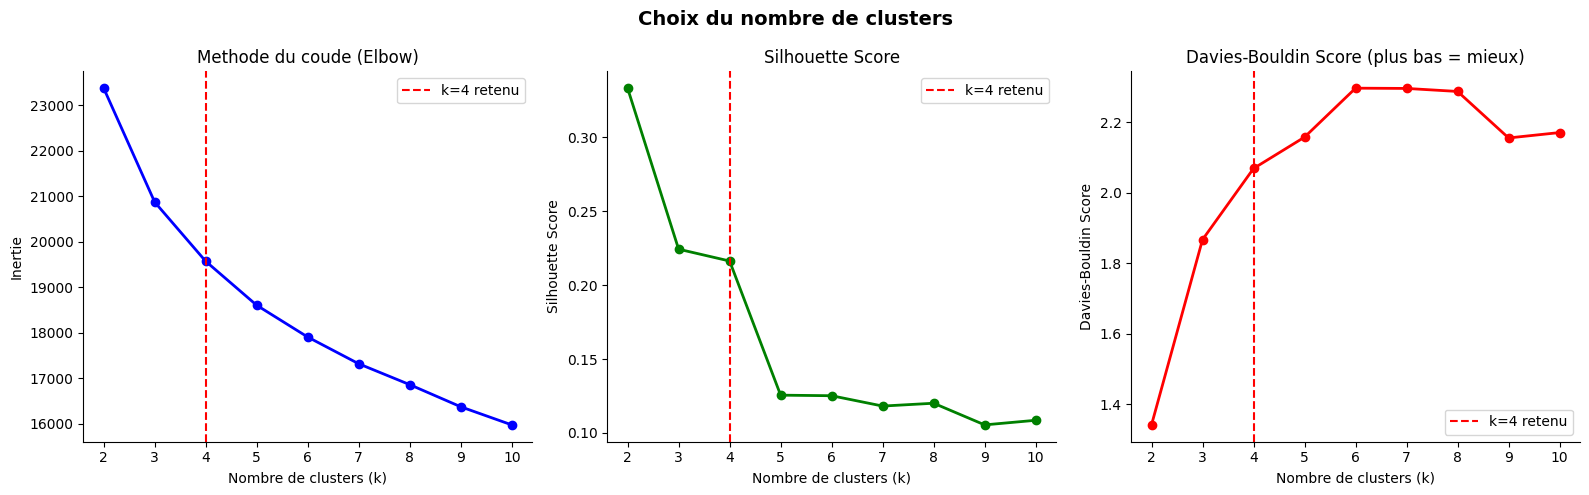

Figure sauvegardée


In [4]:
# ── VISUALISATION ELBOW + SILHOUETTE ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Methode du coude (Elbow)')
axes[0].axvline(4, color='red', linestyle='--', label='k=4 retenu')
axes[0].legend()
sns.despine(ax=axes[0])

# Silhouette
axes[1].plot(list(K_range), silhouettes, 'go-', linewidth=2, markersize=6)
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(4, color='red', linestyle='--', label='k=4 retenu')
axes[1].legend()
sns.despine(ax=axes[1])

# Davies-Bouldin (plus bas = mieux)
axes[2].plot(list(K_range), davies_bouldins, 'ro-', linewidth=2, markersize=6)
axes[2].set_xlabel('Nombre de clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (plus bas = mieux)')
axes[2].axvline(4, color='red', linestyle='--', label='k=4 retenu')
axes[2].legend()
sns.despine(ax=axes[2])

plt.suptitle('Choix du nombre de clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/D_cluster_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée")

In [5]:
# ── 3. KMEANS FINAL — k=4 ────────────────────────────────
# Justification du choix k=4 :
# - Coude visible sur l'inertie autour de k=4
# - Silhouette acceptable
# - 4 segments = granularité exploitable en marketing
# (trop de segments = actions indifférenciables)
# Note : on ajustera si les métriques indiquent un k différent

k_optimal = 4  # à ajuster selon les résultats des métriques
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"K-Means entraîné avec k={k_optimal}")
print(f"\nDistribution des clusters :")
cluster_counts = df['Cluster'].value_counts().sort_index()
for c, n in cluster_counts.items():
    print(f"   Cluster {c} : {n} clients ({n/len(df)*100:.1f}%)")

K-Means entraîné avec k=4

Distribution des clusters :
   Cluster 0 : 553 clients (25.0%)
   Cluster 1 : 1038 clients (46.9%)
   Cluster 2 : 425 clients (19.2%)
   Cluster 3 : 196 clients (8.9%)


In [6]:
# ── 4. PROFILS DES SEGMENTS ───────────────────────────────
profile_vars = ['Income', 'TotalSpend', 'Recency', 'Age',
                'TotalChildren', 'CmpAccepted_Total',
                'MntWines', 'MntMeatProducts', 'Response']

profiles = df.groupby('Cluster')[profile_vars].mean().round(2)
profiles['Taille'] = df['Cluster'].value_counts().sort_index()
profiles['Taille_pct'] = (profiles['Taille'] / len(df) * 100).round(1)

print("=" * 70)
print("PROFILS MOYENS PAR CLUSTER")
print("=" * 70)
print(profiles.to_string())

PROFILS MOYENS PAR CLUSTER
          Income  TotalSpend  Recency   Age  TotalChildren  CmpAccepted_Total  MntWines  MntMeatProducts  Response  Taille  Taille_pct
Cluster                                                                                                                               
0       57594.60      690.11    47.31 59.30           1.07               0.24    434.40           130.24      0.11     553       25.00
1       35128.20       97.53    49.14 52.60           1.26               0.08     43.49            22.81      0.09    1038       46.90
2       72173.43     1261.18    50.21 55.63           0.35               0.15    498.57           414.57      0.17     425       19.20
3       81358.66     1655.15    50.62 55.17           0.24               1.91    908.36           497.82      0.54     196        8.90


VISUALISATION PCA 2D 

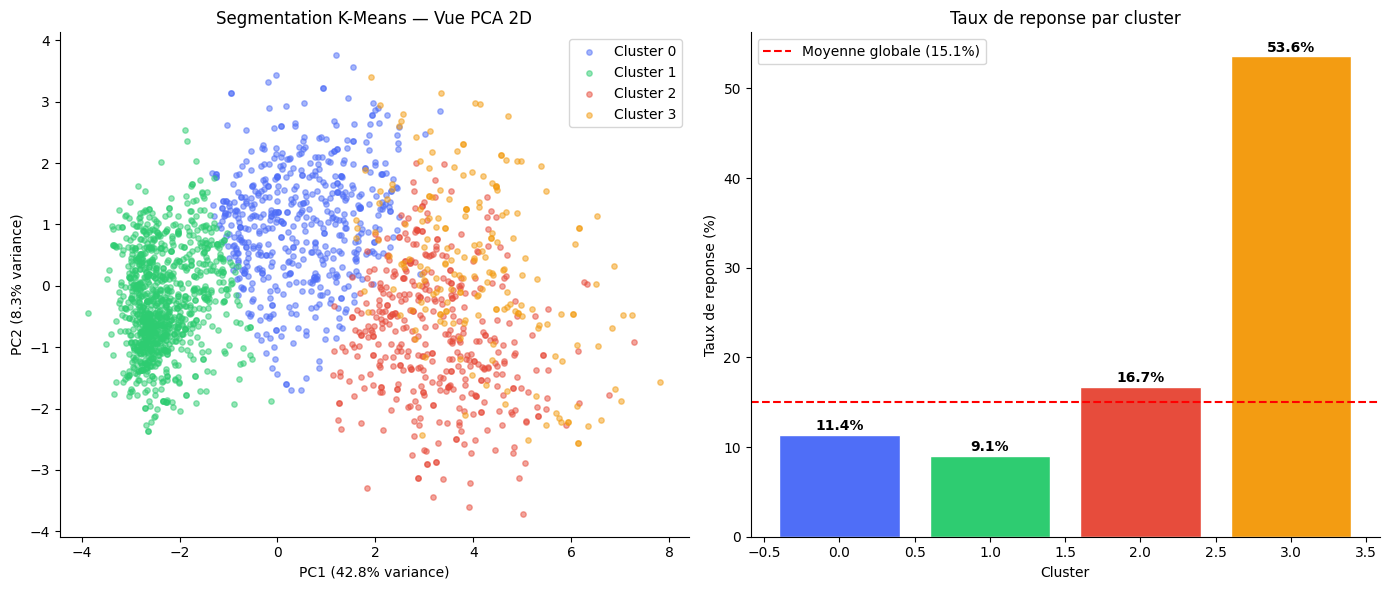


Variance expliquée par PC1+PC2 : 51.2%


In [8]:
# ── 5. VISUALISATION PCA 2D ───────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_cluster = ['#4f6ef7', '#2ecc71', '#e74c3c', '#f39c12']

for cluster in range(k_optimal):
    mask = df['Cluster'] == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_cluster[cluster], label=f'Cluster {cluster}',
                    alpha=0.5, s=15)

axes[0].set_title('Segmentation K-Means — Vue PCA 2D')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()
sns.despine(ax=axes[0])

# Taux de response par cluster
response_by_cluster = df.groupby('Cluster')['Response'].mean() * 100
bars = axes[1].bar(response_by_cluster.index,
                   response_by_cluster.values,
                   color=colors_cluster, edgecolor='white')
for bar, val in zip(bars, response_by_cluster.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Taux de reponse par cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Taux de reponse (%)')
axes[1].axhline(df['Response'].mean()*100, color='red',
                linestyle='--', label=f'Moyenne globale ({df["Response"].mean()*100:.1f}%)')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('../reports/figures/D_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVariance expliquée par PC1+PC2 : "
      f"{(pca.explained_variance_ratio_[:2].sum()*100):.1f}%")

Nommage des segments et sauvegarde

In [10]:
# ── 6. NOMMAGE METIER DES SEGMENTS ───────────────────────
print("=" * 70)
print("NOMMAGE METIER DES SEGMENTS")
print("=" * 70)

segment_names = {
    0: 'Actifs Moyens',
    1: 'Petits Budgets',
    2: 'Aises Passifs',
    3: 'Premium Engages'
}

df['Segment'] = df['Cluster'].map(segment_names)

print("\nRésumé des segments :")
summary = df.groupby('Segment').agg(
    Taille=('Cluster', 'count'),
    Income_moy=('Income', 'mean'),
    TotalSpend_moy=('TotalSpend', 'mean'),
    Response_rate=('Response', 'mean'),
    CmpAccepted_moy=('CmpAccepted_Total', 'mean')
).round(2)
summary['Response_rate'] = (summary['Response_rate'] * 100).round(1)
summary['Taille_pct'] = (summary['Taille'] / len(df) * 100).round(1)
print(summary.to_string())

print("\nAction marketing recommandée par segment :")
actions = {
    'Premium Engages'  : 'Ciblage prioritaire — offres exclusives, programme VIP',
    'Aises Passifs'    : 'Activation — campagnes personnalisées sur vins et viandes',
    'Actifs Moyens'    : 'Nurturing — promotions ciblées, cross-sell',
    'Petits Budgets'   : 'Retention low-cost — deals et réductions uniquement',
}
for segment, action in actions.items():
    print(f"   {segment} : {action}")

# Sauvegarde
df.to_csv('../data/processed/df_clustered.csv', index=False)
print("\nDataset avec segments sauvegardé -> data/processed/df_clustered.csv")

NOMMAGE METIER DES SEGMENTS

Résumé des segments :
                 Taille  Income_moy  TotalSpend_moy  Response_rate  CmpAccepted_moy  Taille_pct
Segment                                                                                        
Actifs Moyens       553    57594.60          690.11          11.00             0.24       25.00
Aises Passifs       425    72173.43         1261.18          17.00             0.15       19.20
Petits Budgets     1038    35128.20           97.53           9.00             0.08       46.90
Premium Engages     196    81358.66         1655.15          54.00             1.91        8.90

Action marketing recommandée par segment :
   Premium Engages : Ciblage prioritaire — offres exclusives, programme VIP
   Aises Passifs : Activation — campagnes personnalisées sur vins et viandes
   Actifs Moyens : Nurturing — promotions ciblées, cross-sell
   Petits Budgets : Retention low-cost — deals et réductions uniquement

Dataset avec segments sauvegardé -> data/